<a href="https://colab.research.google.com/github/folonidaniel4/Redes-Neurais/blob/main/Perceptron_para_fun%C3%A7%C3%B5es_l%C3%B3gicas_AND_OR.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import matplotlib.pyplot as plt

#Função de Ativação (degrau)
def funcao_degrau(x):
  return 1 if x>= 0 else 0

#Função para treinar o perceptron
def treinar_perceptron(X, y, learning_rate=0.1, epochs=100):
  num_features = X.shape[1]
  pesos = np.zeros(num_features + 1)

  for _ in range(epochs):
    for i in range(X.shape[0]):
      #Adiciona o valor de bias ao vetor de entrada
      x = np.insert(X[i], 0, 1)
      #Calcula a saída do perceptron
      saida = funcao_degrau(np.dot(pesos, x))
      #Atualiza os pesos
      pesos += learning_rate * (y[i] - saida) * x

  return pesos

#Função para testar o perceptron
def testar_perceptron(X, pesos):
  num_samples = X.shape[0]
  resultados = np.zeros(num_samples)

  for i in range(num_samples):
    x = np.insert(X[i], 0, 1)
    resultados[i] = funcao_degrau(np.dot(pesos, x))

  return resultados


In [6]:
#Dados de Treinamento
X_train = np.array([[0,0],[0,1],[1,0],[1,1]])
y_and = np.array([0,0,0,1])
y_or = np.array([0,1,1,1])
y_xor = np.array([0,1,1,0])

#Treinamento do Perceptron para função AND
pesos_and = treinar_perceptron(X_train, y_and)
print('Pesos treinados para AND: ', pesos_and)

#Treinamento do Perceptron para função OR
pesos_or = treinar_perceptron(X_train, y_or)
print('Pesos treinados para OR: ',pesos_or)

#Treinamento do Perceptron para função XOR
pesos_xor = treinar_perceptron(X_train, y_xor)
print('Pesos treinados para OR: ',pesos_xor)

#Dados de Teste
X_test = np.array([[0,0],[0,1],[1,0],[1,1]])

#Teste do perceptron para a função AND
resultados_and = testar_perceptron(X_test, pesos_and)
print('Resultados para AND: ', resultados_and)

#Teste do perceptron para a função OR
resultados_or = testar_perceptron(X_test, pesos_or)
print('Resultados para OR: ', resultados_or)

#Teste do perceptron para a função XOR
resultados_xor = testar_perceptron(X_test, pesos_xor)
print('Resultados para OR: ', resultados_xor)


Pesos treinados para AND:  [-0.2  0.2  0.1]
Pesos treinados para OR:  [-0.1  0.1  0.1]
Pesos treinados para OR:  [ 0.  -0.1  0. ]
Resultados para AND:  [0. 0. 0. 1.]
Resultados para OR:  [0. 1. 1. 1.]
Resultados para OR:  [1. 1. 0. 0.]


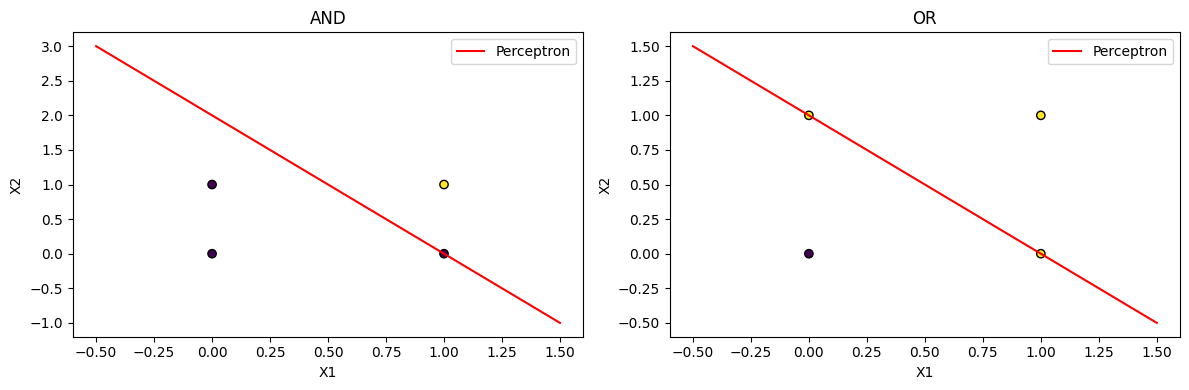

In [14]:
#Visualizando o conjunto de dados a partir de retas ajustadas pelo Perceptron
plt.figure(figsize=(12, 4))

#AND
plt.subplot(1,2,1)
plt.scatter(X_train[:,0], X_train[:,1], c=y_and, cmap='viridis', edgecolors='k')
plt.title('AND')
plt.xlabel('X1')
plt.ylabel('X2')
x = np.linspace(-0.5, 1.5, 100)
y = (-pesos_and[0] - x*pesos_and[1]) / pesos_and[2]
plt.plot(x,y,color='red',label='Perceptron')
plt.legend()

#OR
plt.subplot(1,2,2)
plt.scatter(X_train[:,0], X_train[:,1], c=y_or, cmap='viridis', edgecolors='k')
plt.title('OR')
plt.xlabel('X1')
plt.ylabel('X2')
x = np.linspace(-0.5, 1.5, 100)
y = (-pesos_or[0] - pesos_or[1]*x)/pesos_or[2]
plt.plot(x,y,color='red',label='Perceptron')
plt.legend()

plt.tight_layout()
plt.show()